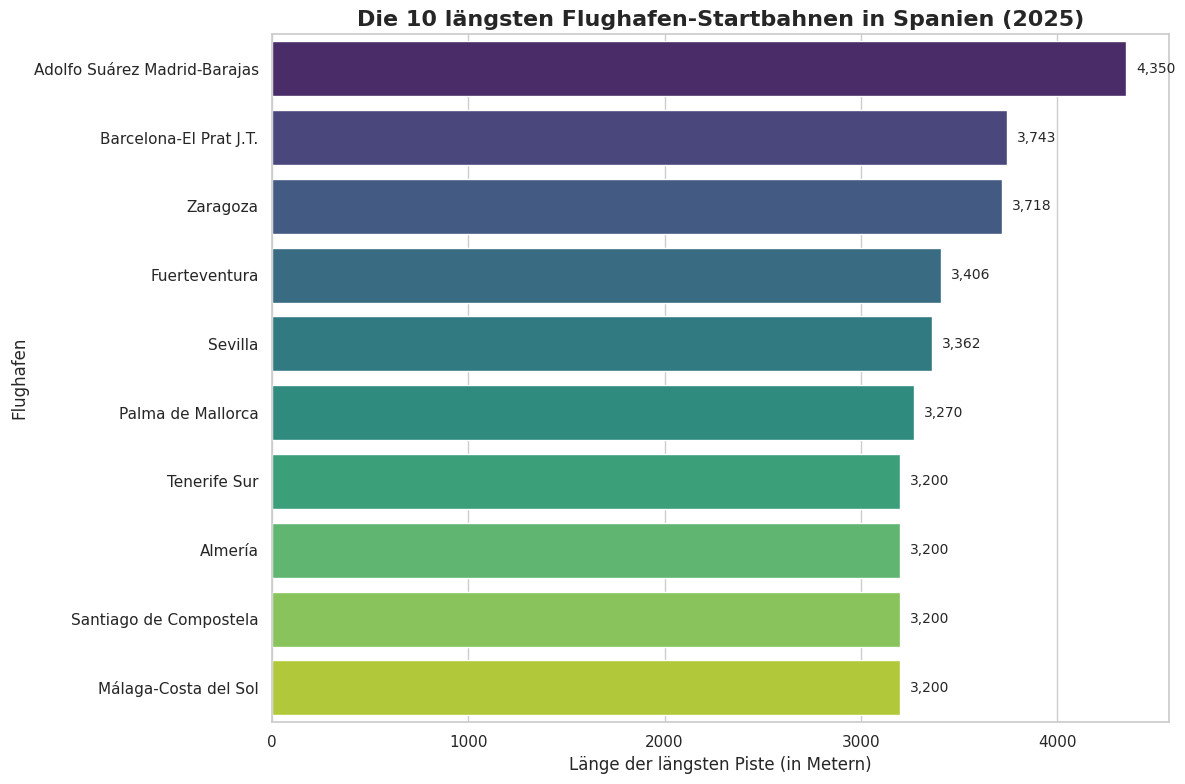

Die Grafik wurde als 'top10_pisten_spanien_2025.png' gespeichert.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pymongo import MongoClient

# --- Schritt 1: Verbindung zur MongoDB ---
client = MongoClient("mongodb://localhost:27017/")
db = client.Espana
collection = db.aeropuerto_stats

# Alle Daten für 2025 laden (ganz Spanien)
query = {"jahr": 2025}
df = pd.DataFrame(list(collection.find(query)))

# --- Schritt 2: Daten vorbereiten ---

# Funktion, um die längste Bahn zu finden (behandelt Arrays und Einzelwerte)
def get_max_runway_length(row):
    # Fall 1: 'pistas' ist ein Array/Liste (wie bei Málaga)
    if isinstance(row.get('pistas'), list):
        if not row['pistas']: # Falls die Liste leer ist
            return 0
        return max(p['pistas_largo'] for p in row['pistas'])
    
    # Fall 2: 'pistas_largo' ist ein Einzelwert (wie bei Sevilla)
    return row.get('pistas_largo', 0)

# Neue Spalte mit der maximalen Bahnlänge erstellen
df['max_piste_laenge'] = df.apply(get_max_runway_length, axis=1)

# Nach Bahnlänge sortieren (absteigend) und die Top 10 nehmen
df_top10 = df.sort_values(by='max_piste_laenge', ascending=False).head(10)

# --- Schritt 3: Visualisierung mit Matplotlib & Seaborn ---

# Seaborn Style setzen (macht es hübscher)
sns.set_theme(style="whitegrid")

# Figur-Größe festlegen
plt.figure(figsize=(12, 8))

# Balkendiagramm erstellen
chart = sns.barplot(
    data=df_top10,
    x='max_piste_laenge',
    y='aeropuerto',
    palette='viridis', # Ein schöner Farbverlauf
    hue='aeropuerto', # Verhindert eine Warnung in neueren Seaborn Versionen
    legend=False
)

# Titel und Achsenbeschriftungen
plt.title('Die 10 längsten Flughafen-Startbahnen in Spanien (2025)', fontsize=16, fontweight='bold')
plt.xlabel('Länge der längsten Piste (in Metern)', fontsize=12)
plt.ylabel('Flughafen', fontsize=12)

# Die tatsächlichen Werte an die Balken schreiben
for i, bar in enumerate(chart.patches):
    width = bar.get_width()
    plt.text(
        width + 50, # X-Position (leicht rechts vom Balken)
        bar.get_y() + bar.get_height() / 2, # Y-Position (mittig im Balken)
        f'{int(width):,}', # Der Wert (formatiert)
        ha='left', va='center', fontsize=10
    )

# Grafik als Datei speichern (für dein Buchmanuskript)
plt.tight_layout()
plt.savefig("top10_pisten_spanien_2025.png", dpi=300) # dpi=300 für hohe Druckqualität

# Grafik anzeigen (falls im Notebook)
plt.show()

print("Die Grafik wurde als 'top10_pisten_spanien_2025.png' gespeichert.")